# Chapter 3.1 Toy Flow Matching from Scratch

This notebook isolates the Chapter 3 toy experiment. The tutorial question is: how does local conditional velocity regression become a learned marginal vector field that can move a source population into a target population?

The toy setting is deliberately two dimensional. Every object - endpoint pairs, conditional paths, velocity targets, the learned vector field, and generated samples - can be inspected before the EB notebooks reuse the same CFM hierarchy in a higher-dimensional biological state space.


## Tutorial setup

These cells set up imports, reproducible run modes, output directories, and generic save/display helpers. The CFM-specific data generation, training, sampling, and plotting logic remains visible in later tutorial cells.


In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

try:
    import torch
except ImportError as exc:
    raise ImportError("This notebook requires PyTorch for CFM training and sampling.") from exc

CWD = Path.cwd().resolve()
root_candidates = [
    CWD,
    CWD.parent,
    CWD.parent.parent,
    CWD / "flow_matching_for_dynamic_biology",
    CWD.parent / "flow_matching_for_dynamic_biology",
    CWD.parent.parent / "flow_matching_for_dynamic_biology",
]
for candidate in root_candidates:
    if (candidate / "src").exists() and (candidate / "notebooks").exists():
        PROJECT_ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not locate project root containing src/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import flow_matching_reporting as ch03
from src.utils import set_seed
from src.models import VelocityMLP, count_parameters
from src.train import train_cfm_steps
from src.sampling import euler_sample


In [2]:
SEED = int(os.environ.get("CH03_SEED", "42"))
set_seed(SEED)

QUICK_MODE = os.environ.get("CH03_QUICK", "1") == "1"
SMOKE_MODE = os.environ.get("CH03_SMOKE_MODE", "0") == "1"
PAPER_FIGURE_MODE = os.environ.get("CH03_PAPER_FIGURE_MODE", "1") == "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

FULL_RUN_HINTS = {
    "eb_train_steps": 10000,
    "cnf_steps": 600,
    "time_ablation_steps": 1200,
    "capacity_steps": 1200,
    "notes": "Set CH03_QUICK=0 for full-run settings; default remains quick and reproducible.",
}

context = ch03.make_ch03_context(PROJECT_ROOT)
FIG_DIR = context.fig_dir
TABLE_DIR = context.table_dir
OUT_DIR = context.output_dir

ch03.set_paper_style()
run_mode = pd.DataFrame(
    [
        {"setting": "project_root", "value": str(PROJECT_ROOT)},
        {"setting": "device", "value": DEVICE},
        {"setting": "seed", "value": SEED},
        {"setting": "quick_mode", "value": QUICK_MODE},
        {"setting": "smoke_mode", "value": SMOKE_MODE},
        {"setting": "paper_figure_mode", "value": PAPER_FIGURE_MODE},
    ]
)
ch03.display_table(run_mode, n=len(run_mode))


,setting,value
0,project_root,/import/macyang_home4/xmabs/flow_matching_for_...
1,device,cuda
2,seed,42
3,quick_mode,True
4,smoke_mode,False
5,paper_figure_mode,True


,setting,value
0,project_root,/import/macyang_home4/xmabs/flow_matching_for_...
1,device,cuda
2,seed,42
3,quick_mode,True
4,smoke_mode,False
5,paper_figure_mode,True


## 1. 2D Toy Sanity Check

The source distribution is eight small Gaussian components on a ring. The target distribution is one rotated Gaussian near the center. CFM never observes a true trajectory here; it samples random endpoint pairs and learns from straight conditional paths between them.


In [4]:
toy_n = 1500 if QUICK_MODE else 5000
if SMOKE_MODE:
    toy_n = 350

toy_steps = 550 if QUICK_MODE else 2200
if SMOKE_MODE:
    toy_steps = 35
toy_log_every = 25 if not SMOKE_MODE else 5

toy_design = pd.DataFrame(
    [
        {"quantity": "toy samples per endpoint distribution", "value": toy_n},
        {"quantity": "training steps", "value": toy_steps},
        {"quantity": "training log interval", "value": toy_log_every},
        {"quantity": "training batch size", "value": 256 if not SMOKE_MODE else 96},
    ]
)
ch03.display_table(toy_design, n=len(toy_design))


,quantity,value
0,toy samples per endpoint distribution,1500
1,training steps,550
2,training log interval,25
3,training batch size,256


,quantity,value
0,toy samples per endpoint distribution,1500
1,training steps,550
2,training log interval,25
3,training batch size,256


In [5]:
toy_X0, toy_components = ch03.make_eight_gaussians(n=toy_n, seed=SEED)
toy_X1 = ch03.make_single_gaussian(n=toy_n, seed=SEED + 1)
toy_pair_batch_fn = ch03.make_random_pair_batch_fn(toy_X0, toy_X1, seed=SEED + 2)

distribution_summary = pd.DataFrame(
    [
        {
            "distribution": "source eight-gaussian mixture",
            "n": len(toy_X0),
            "mean_x": toy_X0[:, 0].mean(),
            "mean_y": toy_X0[:, 1].mean(),
            "std_x": toy_X0[:, 0].std(),
            "std_y": toy_X0[:, 1].std(),
            "components": int(np.unique(toy_components).size),
        },
        {
            "distribution": "target rotated Gaussian",
            "n": len(toy_X1),
            "mean_x": toy_X1[:, 0].mean(),
            "mean_y": toy_X1[:, 1].mean(),
            "std_x": toy_X1[:, 0].std(),
            "std_y": toy_X1[:, 1].std(),
            "components": 1,
        },
    ]
)
ch03.display_table(distribution_summary, n=len(distribution_summary))


,distribution,n,mean_x,mean_y,std_x,std_y,components
0,source eight-gaussian mixture,1500,-0.016612,-0.038014,1.415519,1.414490,8
1,target rotated Gaussian,1500,0.004934,-0.003310,0.419398,0.289226,1


,distribution,n,mean_x,mean_y,std_x,std_y,components
0,source eight-gaussian mixture,1500,-0.016612,-0.038014,1.415519,1.414490,8
1,target rotated Gaussian,1500,0.004934,-0.003310,0.419398,0.289226,1


## 2. Conditional path and local velocity target

For a sampled endpoint pair `(x0, x1)` and time `t`, the conditional path is `x_t = (1 - t) x0 + t x1`. The local regression target is the straight-path velocity `u_t = x1 - x0`. This is conditional because it belongs to one sampled pair; the marginal velocity is what remains after averaging over many possible endpoint pairs that pass near the same state and time.


In [6]:
preview_rng = np.random.default_rng(SEED + 101)
preview_n = 6
preview_i0 = preview_rng.integers(0, len(toy_X0), size=preview_n)
preview_i1 = preview_rng.integers(0, len(toy_X1), size=preview_n)
preview_t = np.linspace(0.1, 0.9, preview_n, dtype=np.float32)
preview_x0 = toy_X0[preview_i0]
preview_x1 = toy_X1[preview_i1]
preview_xt = (1.0 - preview_t[:, None]) * preview_x0 + preview_t[:, None] * preview_x1
preview_ut = preview_x1 - preview_x0

conditional_path_preview = pd.DataFrame(
    {
        "t": preview_t,
        "x0_1": preview_x0[:, 0],
        "x0_2": preview_x0[:, 1],
        "x1_1": preview_x1[:, 0],
        "x1_2": preview_x1[:, 1],
        "x_t_1": preview_xt[:, 0],
        "x_t_2": preview_xt[:, 1],
        "u_t_1": preview_ut[:, 0],
        "u_t_2": preview_ut[:, 1],
    }
)
ch03.display_table(conditional_path_preview.round(3), n=preview_n)


,t,x0_1,x0_2,x1_1,x1_2,x_t_1,x_t_2,u_t_1,u_t_2
0,0.10,-2.023,0.019,0.262,-0.516,-1.794,-0.034,2.284,-0.536
1,0.26,1.391,1.367,0.020,0.277,1.035,1.084,-1.371,-1.090
2,0.42,-0.067,-2.142,-0.165,0.300,-0.108,-1.116,-0.098,2.442
3,0.58,2.114,0.021,0.027,-0.149,0.904,-0.078,-2.087,-0.169
4,0.74,-2.042,-0.000,0.108,-0.165,-0.451,-0.122,2.150,-0.165
5,0.90,1.411,1.407,0.407,0.108,0.508,0.238,-1.004,-1.299


,t,x0_1,x0_2,x1_1,x1_2,x_t_1,x_t_2,u_t_1,u_t_2
0,0.10,-2.023,0.019,0.262,-0.516,-1.794,-0.034,2.284,-0.536
1,0.26,1.391,1.367,0.020,0.277,1.035,1.084,-1.371,-1.090
2,0.42,-0.067,-2.142,-0.165,0.300,-0.108,-1.116,-0.098,2.442
3,0.58,2.114,0.021,0.027,-0.149,0.904,-0.078,-2.087,-0.169
4,0.74,-2.042,-0.000,0.108,-0.165,-0.451,-0.122,2.150,-0.165
5,0.90,1.411,1.407,0.407,0.108,0.508,0.238,-1.004,-1.299


## 3. Learn the marginal velocity field

Training repeatedly samples endpoint pairs and times, computes the conditional target `x1 - x0`, and updates `VelocityMLP(x_t, t)` by local mean-squared error. The network is the marginal field estimator: it cannot memorize one endpoint path, so it must represent the local average behavior induced by many paths.


In [7]:
toy_model = VelocityMLP(x_dim=2, hidden_dim=128, hidden_layers=4).to(DEVICE)
toy_optimizer = torch.optim.Adam(toy_model.parameters(), lr=1e-3)

model_summary = pd.DataFrame(
    [
        {"object": "VelocityMLP", "role": "marginal vector-field estimator"},
        {"object": "input x_t", "role": "current 2D state on a conditional path"},
        {"object": "input t", "role": "continuous interpolation time"},
        {"object": "output v_theta(x_t,t)", "role": "predicted local velocity"},
        {"object": "parameters", "role": int(count_parameters(toy_model))},
    ]
)
ch03.display_table(model_summary, n=len(model_summary))


,object,role
0,VelocityMLP,marginal vector-field estimator
1,input x_t,current 2D state on a conditional path
2,input t,continuous interpolation time
3,"output v_theta(x_t,t)",predicted local velocity
4,parameters,50306


,object,role
0,VelocityMLP,marginal vector-field estimator
1,input x_t,current 2D state on a conditional path
2,input t,continuous interpolation time
3,"output v_theta(x_t,t)",predicted local velocity
4,parameters,50306


In [8]:
toy_history = train_cfm_steps(
    toy_model,
    toy_pair_batch_fn,
    toy_optimizer,
    n_steps=toy_steps,
    batch_size=256 if not SMOKE_MODE else 96,
    device=DEVICE,
    log_every=toy_log_every,
)


In [9]:
loss_preview = toy_history.tail(8).copy()
ch03.display_table(loss_preview, n=len(loss_preview))


,method,step,loss,wall_time_sec,sec_per_step,nfe_train_per_step,batch_size
15,cfm_local_regression,375,0.757479,2.895610,0.001803,1,256
16,cfm_local_regression,400,0.639064,2.957093,0.002459,1,256
17,cfm_local_regression,425,0.616163,3.002283,0.001808,1,256
18,cfm_local_regression,450,0.739006,3.047361,0.001803,1,256
19,cfm_local_regression,475,0.740500,3.092430,0.001803,1,256
20,cfm_local_regression,500,0.730800,3.137706,0.001811,1,256
21,cfm_local_regression,525,0.645052,3.182699,0.001800,1,256
22,cfm_local_regression,550,0.546526,3.227784,0.001803,1,256


,method,step,loss,wall_time_sec,sec_per_step,nfe_train_per_step,batch_size
15,cfm_local_regression,375,0.757479,2.895610,0.001803,1,256
16,cfm_local_regression,400,0.639064,2.957093,0.002459,1,256
17,cfm_local_regression,425,0.616163,3.002283,0.001808,1,256
18,cfm_local_regression,450,0.739006,3.047361,0.001803,1,256
19,cfm_local_regression,475,0.740500,3.092430,0.001803,1,256
20,cfm_local_regression,500,0.730800,3.137706,0.001811,1,256
21,cfm_local_regression,525,0.645052,3.182699,0.001800,1,256
22,cfm_local_regression,550,0.546526,3.227784,0.001803,1,256


In [10]:
fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.plot(toy_history["step"], toy_history["loss"], color="#2F6B5E", linewidth=1.6)
ax.set_xlabel("optimization step")
ax.set_ylabel("CFM local MSE")
ax.set_title("Toy CFM training loss")
ax.grid(axis="y", color="0.92", linewidth=0.7)
toy_loss_path = ch03.save_and_close_figure(fig, FIG_DIR, "fig_toy_loss.png", write_pdf=PAPER_FIGURE_MODE)


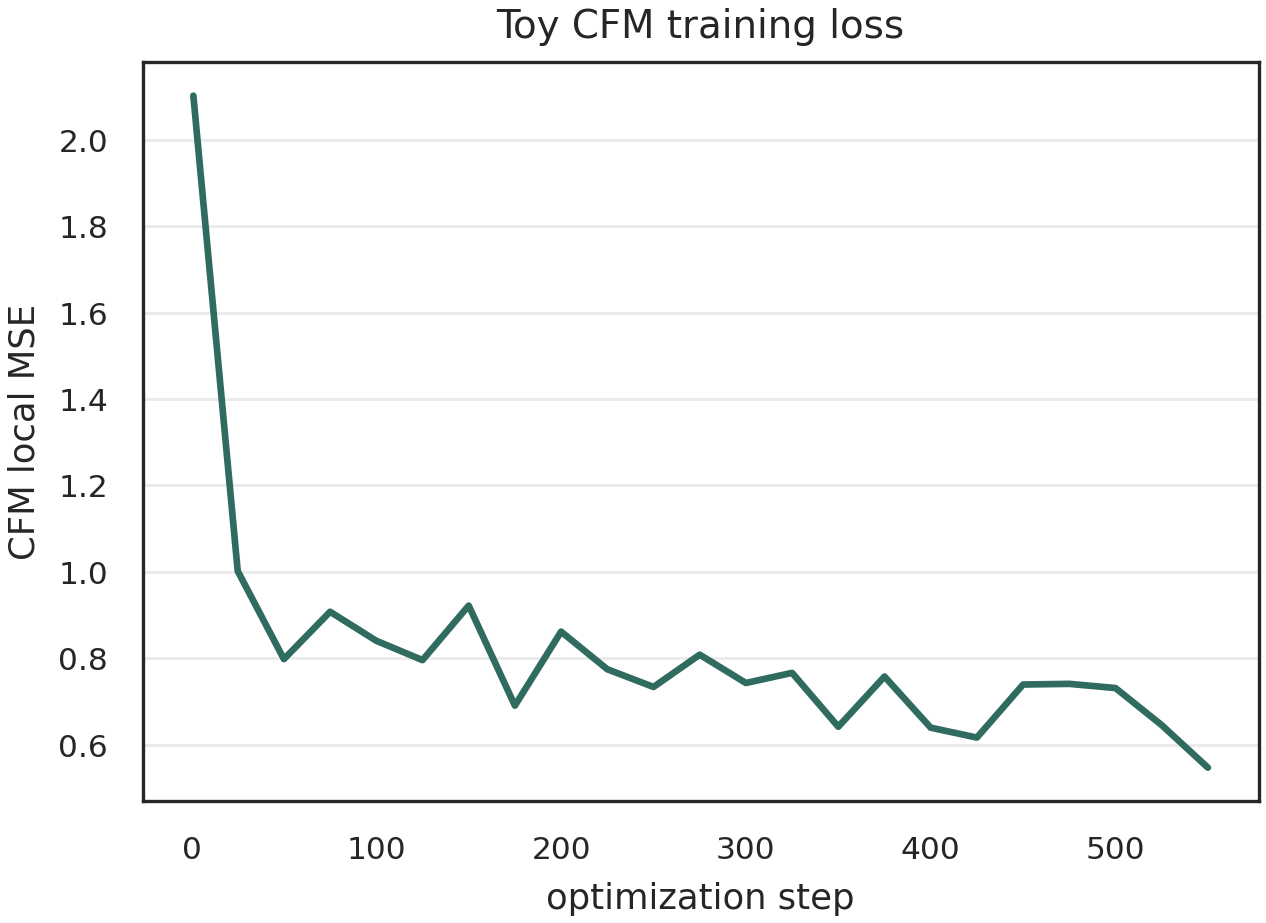

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/fig_toy_loss.png')

In [11]:
ch03.display_saved_figure(toy_loss_path, width=620)


## 4. Roll out the learned field

Sampling now uses the learned marginal vector field as an ODE velocity. Euler integration starts from source particles and repeatedly applies `dx/dt = v_theta(x,t)`. This checks whether local CFM regression learned a population-level transport map in the toy space.


In [12]:
toy_model.eval()
toy_sample_n = min(900 if QUICK_MODE else 1800, len(toy_X0))
if SMOKE_MODE:
    toy_sample_n = min(220, len(toy_X0))

toy_sample_idx = ch03.subsample_idx(len(toy_X0), toy_sample_n, seed=SEED + 3)
toy_x0_t = torch.as_tensor(toy_X0[toy_sample_idx], dtype=torch.float32, device=DEVICE)
toy_euler_steps = 100 if not SMOKE_MODE else 25

sampling_design = pd.DataFrame(
    [
        {"quantity": "sampled source particles", "value": toy_sample_n},
        {"quantity": "Euler steps", "value": toy_euler_steps},
        {"quantity": "return full trajectory", "value": True},
    ]
)
ch03.display_table(sampling_design, n=len(sampling_design))


,quantity,value
0,sampled source particles,900
1,Euler steps,100
2,return full trajectory,True


,quantity,value
0,sampled source particles,900
1,Euler steps,100
2,return full trajectory,True


In [13]:
with torch.no_grad():
    toy_final_t, toy_traj_t, toy_nfe = euler_sample(
        toy_model,
        toy_x0_t,
        n_steps=toy_euler_steps,
        return_traj=True,
    )
toy_traj = ch03.as_np(toy_traj_t)


In [14]:
trajectory_summary = pd.DataFrame(
    [
        {"quantity": "trajectory tensor shape", "value": str(tuple(toy_traj.shape))},
        {"quantity": "Euler NFE", "value": int(toy_nfe)},
        {"quantity": "initial mean x", "value": float(toy_traj[0, :, 0].mean())},
        {"quantity": "final mean x", "value": float(toy_traj[-1, :, 0].mean())},
        {"quantity": "initial mean y", "value": float(toy_traj[0, :, 1].mean())},
        {"quantity": "final mean y", "value": float(toy_traj[-1, :, 1].mean())},
    ]
)
ch03.display_table(trajectory_summary, n=len(trajectory_summary))


,quantity,value
0,trajectory tensor shape,"(101, 900, 2)"
1,Euler NFE,100
2,initial mean x,-0.052843
3,final mean x,0.048435
4,initial mean y,-0.033758
5,final mean y,0.002799


,quantity,value
0,trajectory tensor shape,"(101, 900, 2)"
1,Euler NFE,100
2,initial mean x,-0.052843
3,final mean x,0.048435
4,initial mean y,-0.033758
5,final mean y,0.002799


In [15]:
toy_times = [0.0, 0.25, 0.5, 0.75, 1.0]
toy_step_idx = np.round(np.asarray(toy_times) * (toy_traj.shape[0] - 1)).astype(int)
xlim, ylim = ch03.robust_limits(toy_X0, toy_X1, toy_traj.reshape(-1, 2), margin=0.10)
fig, axes = plt.subplots(1, 5, figsize=(12.3, 2.65), sharex=True, sharey=True)
target_idx = ch03.subsample_idx(len(toy_X1), 450, seed=61)
for ax, tau, step in zip(axes, toy_times, toy_step_idx):
    pts = toy_traj[step]
    ax.scatter(toy_X1[target_idx, 0], toy_X1[target_idx, 1], s=5, color="0.72", alpha=0.20, linewidths=0)
    ax.scatter(pts[:, 0], pts[:, 1], s=6, color="#2F6B5E", alpha=0.52, linewidths=0)
    ch03.format_axis(ax, xlim, ylim, xlabel="toy x1", ylabel="toy x2", title=f"t={tau:.2f}")
    if ax is not axes[0]:
        ax.set_ylabel("")
fig.suptitle("Toy population evolution under Euler sampling")
toy_evolution_path = ch03.save_and_close_figure(fig, FIG_DIR, "fig_toy_evolution.png", write_pdf=PAPER_FIGURE_MODE)


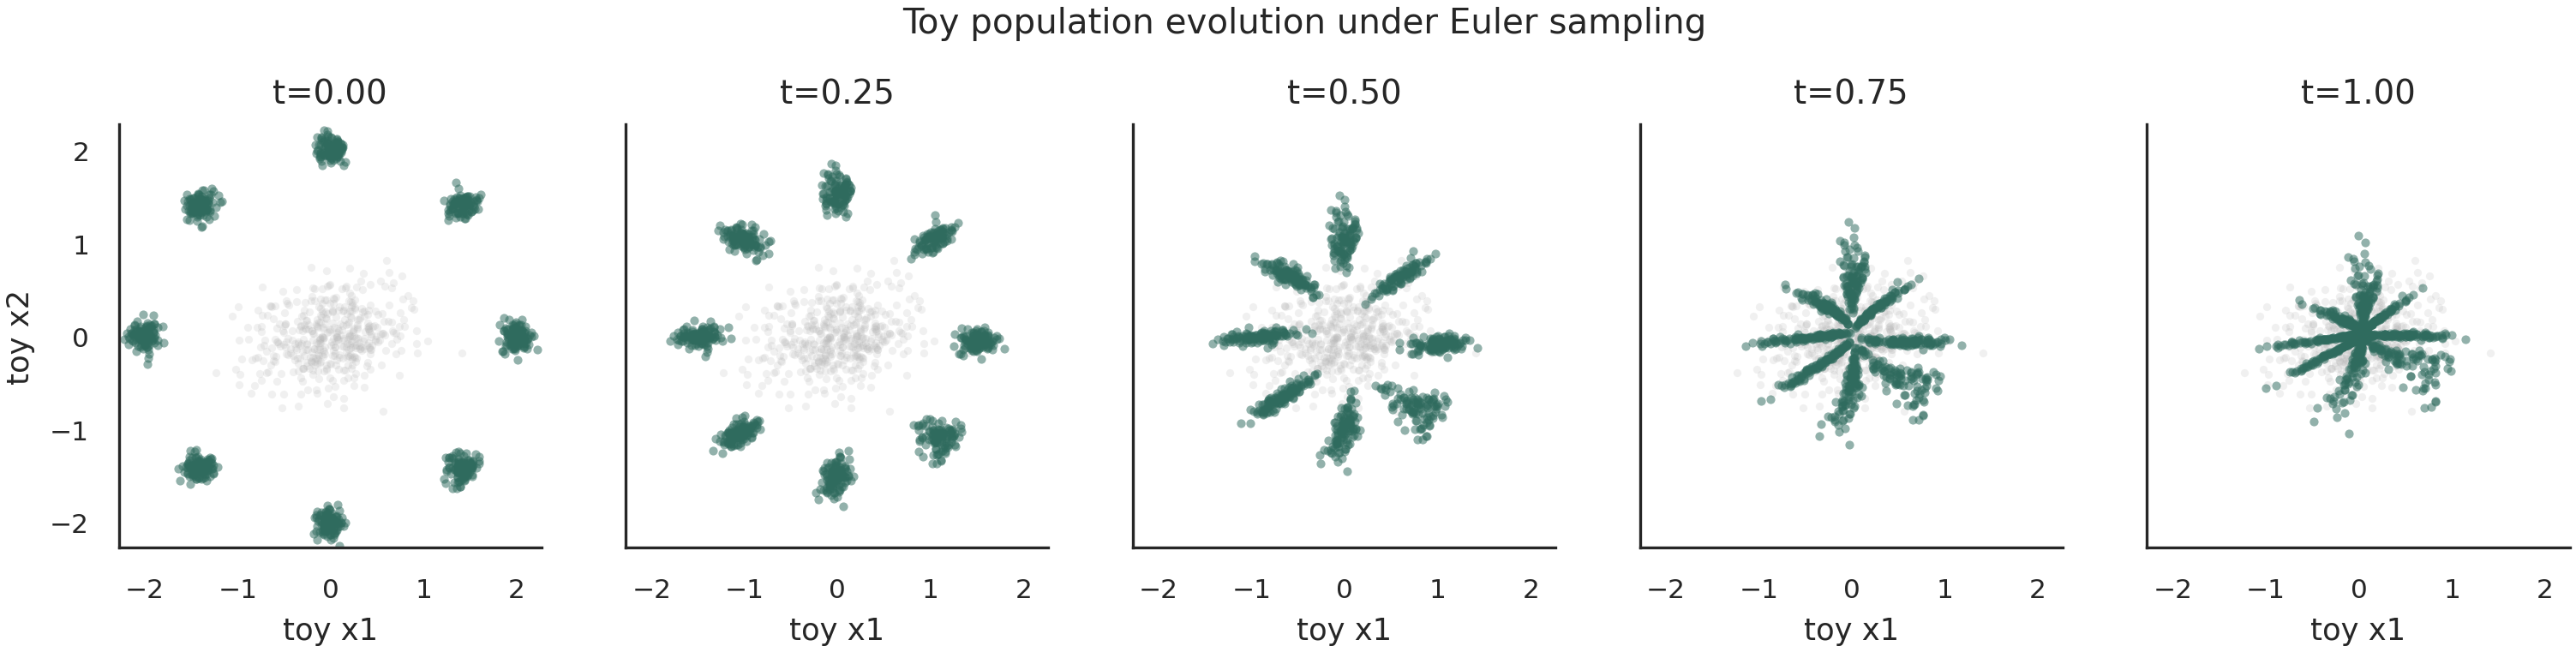

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/fig_toy_evolution.png')

In [16]:
ch03.display_saved_figure(toy_evolution_path, width=900)


### Figure 3.2: Conditional Velocity Versus Marginal Velocity

This panel inspects the distinction that CFM relies on. Around one local state at `t=0.5`, many conditional endpoint pairs imply different straight-line velocities. Their local average is the Monte Carlo target for the marginal velocity field. The trained network predicts one vector at that state and time.


In [17]:
toy_velocity_probe = ch03.build_toy_velocity_probe(toy_model, toy_X0, toy_X1, device=DEVICE, seed=SEED + 4)


In [18]:
velocity_probe_summary = pd.DataFrame(
    [
        {"object": "local conditional velocities", "value": int(len(toy_velocity_probe["local"]))},
        {"object": "probe time", "value": toy_velocity_probe["t_value"]},
        {"object": "probe center x", "value": toy_velocity_probe["center"][0]},
        {"object": "probe center y", "value": toy_velocity_probe["center"][1]},
        {"object": "mean conditional velocity x", "value": toy_velocity_probe["mean_conditional_velocity"][0]},
        {"object": "network velocity x", "value": toy_velocity_probe["network_velocity"][0]},
        {"object": "mean conditional velocity y", "value": toy_velocity_probe["mean_conditional_velocity"][1]},
        {"object": "network velocity y", "value": toy_velocity_probe["network_velocity"][1]},
    ]
)
ch03.display_table(velocity_probe_summary.round(4), n=len(velocity_probe_summary))


,object,value
0,local conditional velocities,120.0000
1,probe time,0.5000
2,probe center x,-0.0199
3,probe center y,-0.0174
4,mean conditional velocity x,0.4152
5,network velocity x,0.3656
6,mean conditional velocity y,0.0792
7,network velocity y,0.3684


,object,value
0,local conditional velocities,120.0000
1,probe time,0.5000
2,probe center x,-0.0199
3,probe center y,-0.0174
4,mean conditional velocity x,0.4152
5,network velocity x,0.3656
6,mean conditional velocity y,0.0792
7,network velocity y,0.3684


In [19]:
fig = ch03.plot_toy_conditional_vs_marginal(toy_model, toy_X0, toy_X1, toy_velocity_probe)
toy_fig32_path = ch03.save_and_close_figure(fig, FIG_DIR, "fig03_02_conditional_vs_marginal_toy.png", write_pdf=PAPER_FIGURE_MODE)


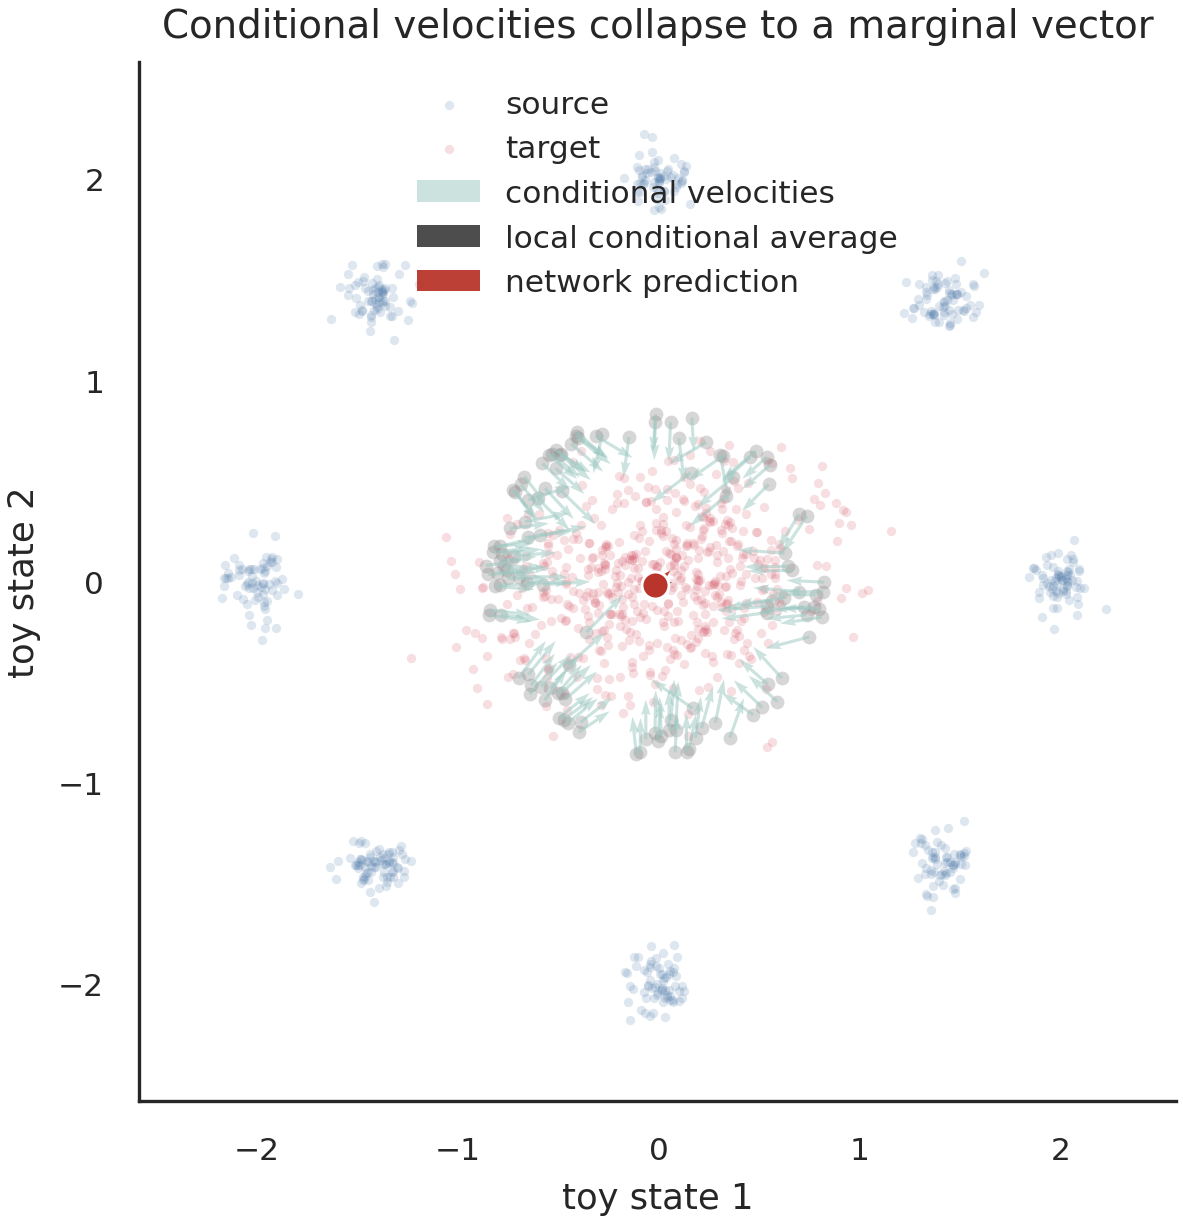

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/fig03_02_conditional_vs_marginal_toy.png')

In [20]:
ch03.display_saved_figure(toy_fig32_path, width=620)


### Figure 3.3: CFM Object Hierarchy

CFM has a hierarchy of objects. At the bottom is one endpoint-conditioned straight path. A batch gives many such paths. The model is not one of those paths; it is an Eulerian vector field that summarizes the marginal velocity at each state and time.


In [21]:
toy_hierarchy = ch03.prepare_toy_hierarchy_objects(toy_model, toy_X0, toy_X1, device=DEVICE, seed=SEED + 5)


In [22]:
hierarchy_preview = pd.DataFrame(
    [
        {"level": "one endpoint pair", "object": "x0, x1", "visible_in_panel": "A"},
        {"level": "one conditional path", "object": "x_t = (1 - t)x0 + t x1", "visible_in_panel": "A"},
        {"level": "path population", "object": "many independently sampled endpoint pairs", "visible_in_panel": "B"},
        {"level": "marginal velocity field", "object": "v_theta(x,t) over a grid at t=0.5", "visible_in_panel": "C"},
    ]
)
ch03.display_table(hierarchy_preview, n=len(hierarchy_preview))


,level,object,visible_in_panel
0,one endpoint pair,"x0, x1",A
1,one conditional path,x_t = (1 - t)x0 + t x1,A
2,path population,many independently sampled endpoint pairs,B
3,marginal velocity field,"v_theta(x,t) over a grid at t=0.5",C


,level,object,visible_in_panel
0,one endpoint pair,"x0, x1",A
1,one conditional path,x_t = (1 - t)x0 + t x1,A
2,path population,many independently sampled endpoint pairs,B
3,marginal velocity field,"v_theta(x,t) over a grid at t=0.5",C


In [23]:
fig = ch03.plot_toy_cfm_object_hierarchy(toy_X0, toy_X1, toy_hierarchy)
toy_hierarchy_path = ch03.save_and_close_figure(fig, FIG_DIR, "fig03_03_cfm_object_hierarchy_toy.png", write_pdf=PAPER_FIGURE_MODE)


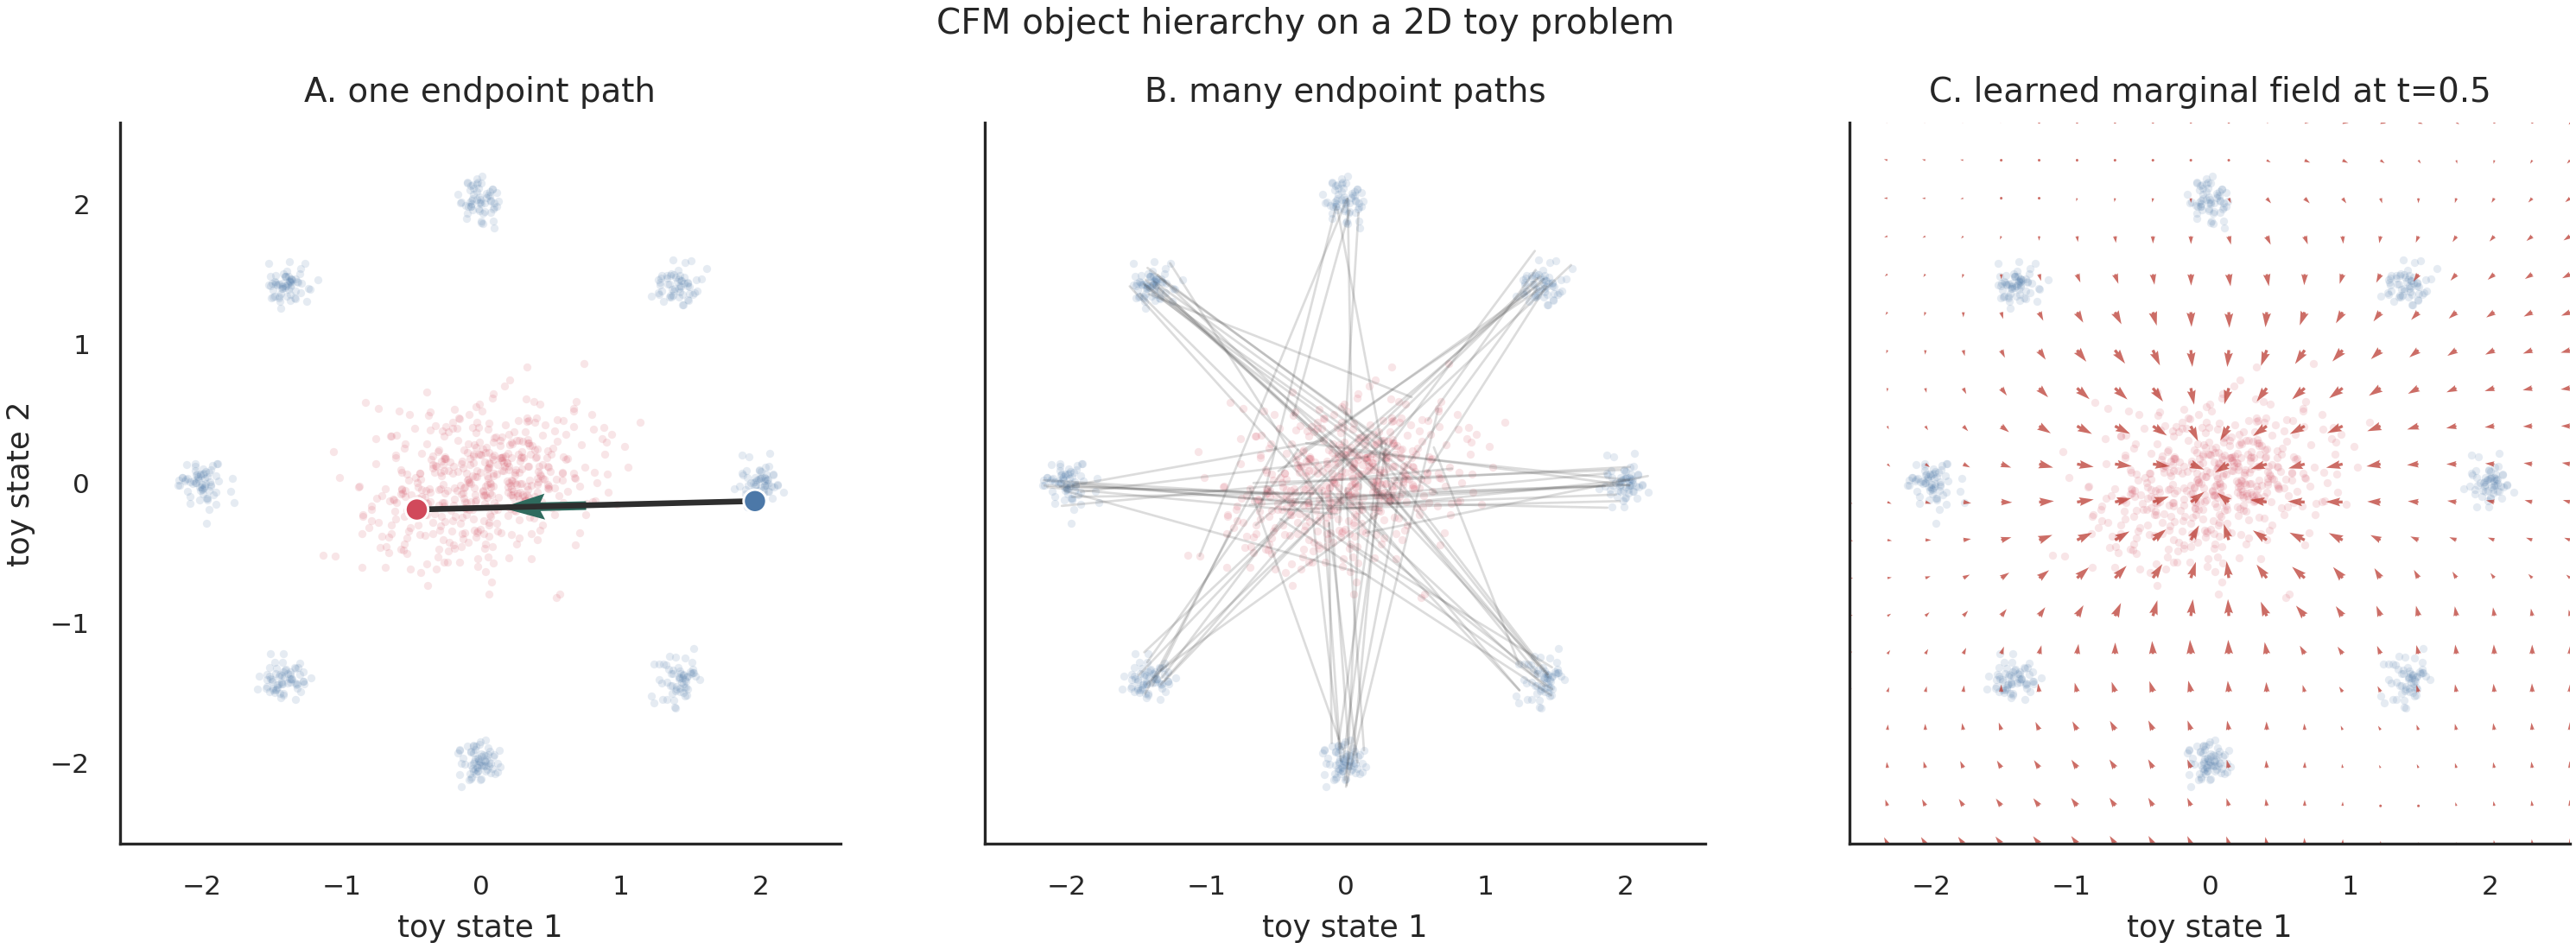

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/fig03_03_cfm_object_hierarchy_toy.png')

In [24]:
ch03.display_saved_figure(toy_hierarchy_path, width=900)
